In [4]:
pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 9.7 MB/s  0:00:016m0:00:010:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 7.5 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# Get all bszz label files
file_pattern = '/home/afler/Documents/thesis-later/results/phase1/bszz_*_labels.csv'
files = glob.glob(file_pattern)

data = []
for file in files:
    filename = os.path.basename(file)
    # extract repo name, e.g. bszz_ant-ivy_labels.csv -> ant-ivy
    repo_name = filename.replace('bszz_', '').replace('_labels.csv', '')
    
    df = pd.read_csv(file)
    total_commits = len(df)
    bug_commits = df['label_BSZZ'].sum() if 'label_BSZZ' in df.columns else df.iloc[:, 1].sum()
    
    data.append({
        'Repository': repo_name,
        'Total Commits': total_commits,
        'Bug Commits': bug_commits
    })

df_summary = pd.DataFrame(data)
df_summary = df_summary.sort_values('Total Commits', ascending=False)

display(df_summary)


,Repository,Total Commits,Bug Commits
5,commons-lang,9712,846
8,commons-math,7441,1309
7,commons-compress,6894,316
0,commons-io,6260,405
6,commons-collections,5312,712
12,commons-configuration,4813,640
11,commons-vfs,4705,565
16,commons-net,4303,232
9,commons-bcel,3727,137
15,commons-dbcp,3616,563


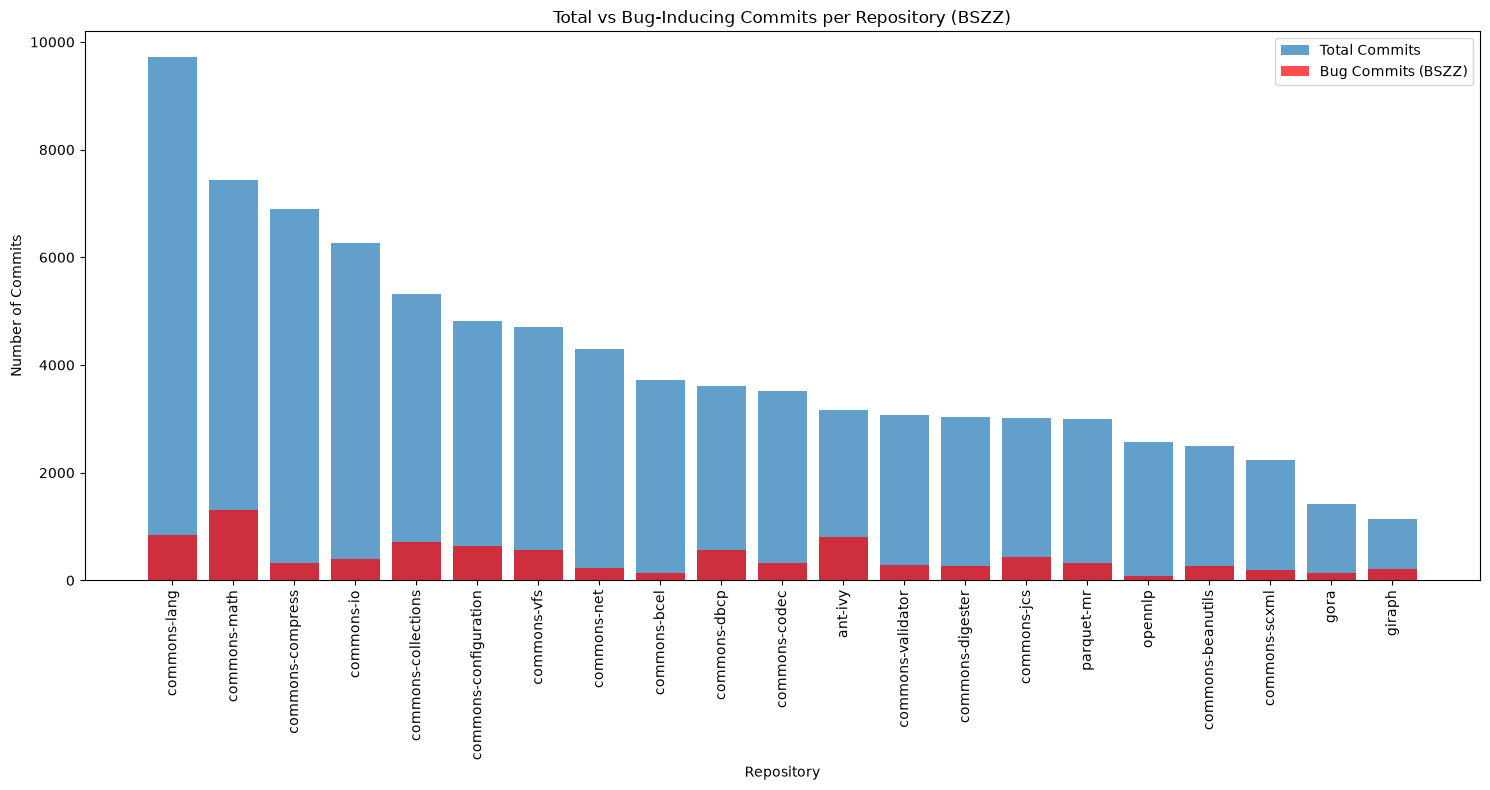

In [2]:
# Plotting
plt.figure(figsize=(15, 8))
plt.bar(df_summary['Repository'], df_summary['Total Commits'], label='Total Commits', alpha=0.7)
plt.bar(df_summary['Repository'], df_summary['Bug Commits'], label='Bug Commits (BSZZ)', color='red', alpha=0.7)
plt.xticks(rotation=90)
plt.xlabel('Repository')
plt.ylabel('Number of Commits')
plt.title('Total vs Bug-Inducing Commits per Repository (BSZZ)')
plt.legend()
plt.tight_layout()
plt.savefig('viz_bszz.png') # Save to an image file
plt.show()
